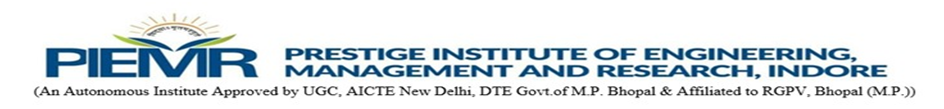

<h2 align="left">Department of AI & Data Science</h2>

<h2 align="left">Data Mining & Warehousing Lab </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>

# EXPERIMENT 10 SPAM MESSAGE CLASSIFICATION USING NAIVE BAYES

## IMPORT LIBRARIES

In this experiment, we will build a Spam Message Classification System.

Spam classification helps us:
- Detect spam messages
- Filter unwanted SMS
- Improve security

IMPORT DATASET

Read the SMS Spam Collection dataset from the local system.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [13]:
path = r"C:\Users\rjesh\SMSSpamCollection.csv"

with open(path, 'r', encoding='latin-1') as f:
    lines = f.readlines()

print("Total lines:", len(lines))
print("Sample line:", lines[0])



Total lines: 5574
Sample line: ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...



CREATE DATAFRAME

Separate labels and messages from the dataset.

In [14]:
data = []

for line in lines:
    parts = line.strip().split('\t', 1)  # split only first tab
    
    if len(parts) == 2:
        label = parts[0].strip()
        message = parts[1].strip()
        
        data.append([label, message])

df = pd.DataFrame(data, columns=['label', 'message'])

df.head()



,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


DATASET INFORMATION

Display dataset details

In [15]:
print(df['label'].value_counts())
print(df.shape)




ham     4827
spam     747
Name: label, dtype: int64
(5574, 2)


DATA PREPROCESSING

Machine Learning models work better when labels are converted into numerical values.

Convert labels:

ham → 0
spam → 1

In [16]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})



FEATURE EXTRACTION

Text data cannot be directly used in Machine Learning algorithms.

We use CountVectorizer to convert text messages into numerical feature vectors.

CountVectorizer performs:

Tokenization
Vocabulary creation
Word frequency counting
Text vectorization

TRAIN TEST SPLIT

Split dataset into training and testing data.

Training data → used to train the model
Testing data → used to evaluate the model
TRANSFORM TEXT DATA

Convert text messages into numerical vectors.

In [18]:
vectorizer = CountVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)



NAIVE BAYES ALGORITHM

Naive Bayes is a probabilistic Machine Learning algorithm commonly used for:

Spam Detection
Sentiment Analysis
Text Classification
Email Filtering
NLP Applications

Advantages:

Fast and efficient
Works well with text data
Requires less training data
High performance for classification tasks

TRAIN MODEL

Train the Multinomial Naive Bayes classifier.

In [39]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)



,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


MAKE PREDICTIONS

Predict whether messages are spam or ham.

In [20]:
y_pred = model.predict(X_test_vec)



MODEL ACCURACY

Accuracy measures how many predictions are correct.

Formula:

Accuracy = Correct Predictions / Total Predictions

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.9847533632286996


Interpretation:

Higher accuracy indicates better model performance.
Accuracy close to 1 means highly accurate classification.

CONFUSION MATRIX

A confusion matrix helps evaluate classification performance.

It contains:

True Positives
True Negatives
False Positives
False Negatives

In [22]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[948   6]
 [ 11 150]]


The classification report provides:

Precision
Recall
F1-score
Support

In [23]:
print("Classification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       954
           1       0.96      0.93      0.95       161

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



PRECISION

Precision measures how many predicted spam messages are actually spam.

Formula:

Precision = True Positives / (True Positives + False Positives)

Interpretation:

High precision means fewer false spam detections.

RECALL

Recall measures how many actual spam messages are correctly detected.

Formula:

Recall = True Positives / (True Positives + False Negatives)

Interpretation:

High recall means fewer spam messages are missed.

F1-SCORE

F1-score is the harmonic mean of Precision and Recall.

Formula:

F1-score = 2 × (Precision × Recall) / (Precision + Recall)

Interpretation:

Higher F1-score indicates balanced performance.

SAMPLE PREDICTION

Test the model on a custom message.

In [24]:
messages = [
    "Congratulations! You won a free iPhone. Click now!",
    "Hey, are we meeting tomorrow?",
    "Urgent! Your bank account is blocked. Verify immediately!"
]

msg_vec = vectorizer.transform(messages)

pred = model.predict(msg_vec)

for m, p in zip(messages, pred):
    print(f"\nMessage: {m}")
    print("Prediction:", "SPAM 🚫" if p == 1 else "HAM ✅")
    
    


Message: Congratulations! You won a free iPhone. Click now!
Prediction: SPAM 🚫

Message: Hey, are we meeting tomorrow?
Prediction: HAM ✅

Message: Urgent! Your bank account is blocked. Verify immediately!
Prediction: SPAM 🚫


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns



In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)



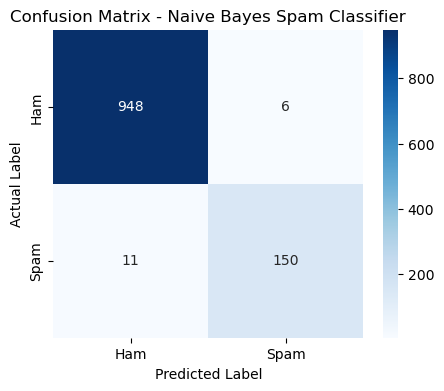

In [27]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Naive Bayes Spam Classifier")

plt.show()



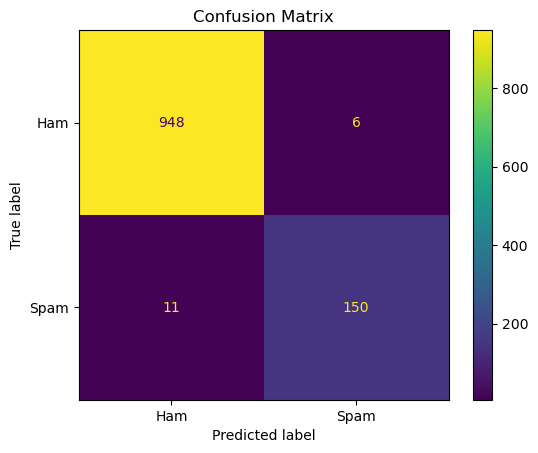

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Ham','Spam'])
plt.title("Confusion Matrix")
plt.show()



In [30]:
pip install wordcloud seaborn matplotlib


     ------------------------------------ 306.2/306.2 kB 902.4 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud



VISUALIZATION

Visualize the distribution of spam and ham messages.

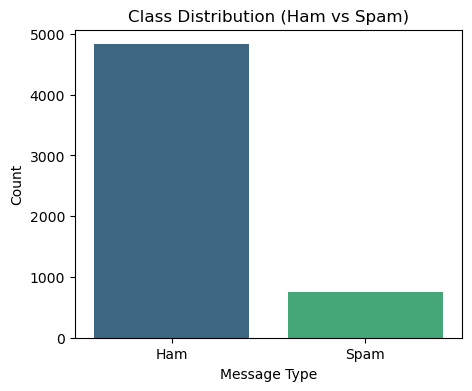

In [32]:
plt.figure(figsize=(5,4))

sns.countplot(x=df['label'], palette='viridis')

plt.xticks([0,1], ['Ham', 'Spam'])
plt.title("Class Distribution (Ham vs Spam)")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()



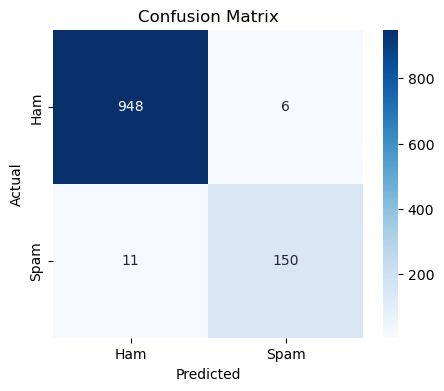

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()



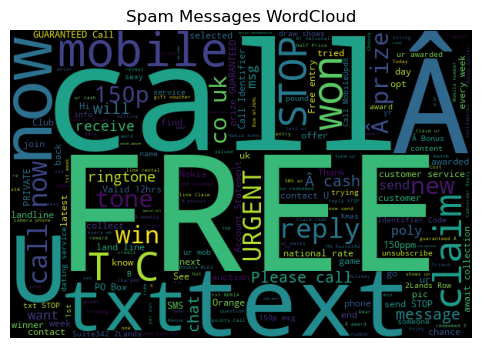

In [34]:
spam_words = " ".join(df[df['label']==1]['message'])

wordcloud_spam = WordCloud(width=600, height=400, background_color='black').generate(spam_words)

plt.figure(figsize=(6,4))
plt.imshow(wordcloud_spam)
plt.axis('off')
plt.title("Spam Messages WordCloud")
plt.show()



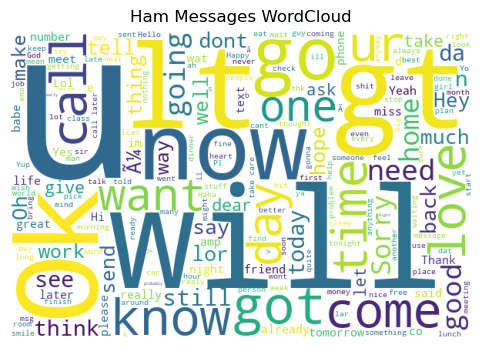

In [35]:
ham_words = " ".join(df[df['label']==0]['message'])

wordcloud_ham = WordCloud(width=600, height=400, background_color='white').generate(ham_words)

plt.figure(figsize=(6,4))
plt.imshow(wordcloud_ham)
plt.axis('off')
plt.title("Ham Messages WordCloud")
plt.show()



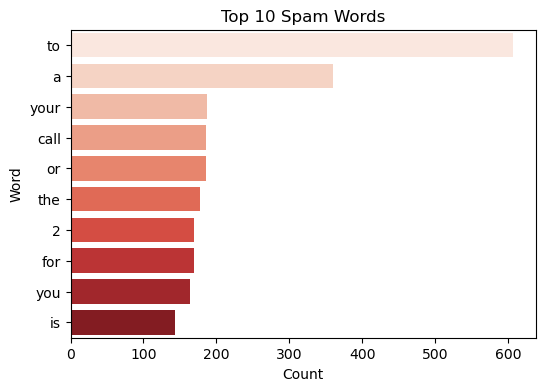

In [36]:
from collections import Counter

spam_text = " ".join(df[df['label']==1]['message'])
words = spam_text.split()

common_words = Counter(words).most_common(10)

words_df = pd.DataFrame(common_words, columns=['Word','Count'])

plt.figure(figsize=(6,4))
sns.barplot(x='Count', y='Word', data=words_df, palette='Reds')

plt.title("Top 10 Spam Words")
plt.show()



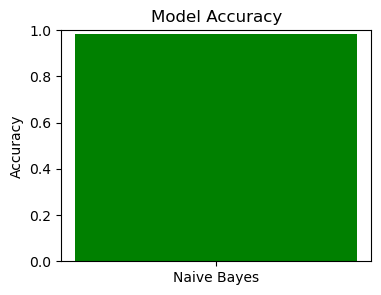

In [37]:
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(4,3))
plt.bar(['Naive Bayes'], [acc], color='green')

plt.ylim(0,1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")

plt.show()



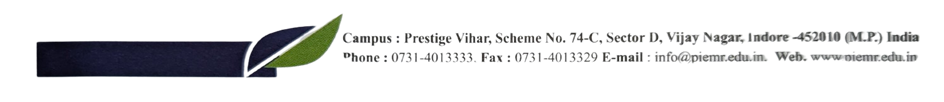